# Imports


In [3]:
import gymnasium as gym
import lantern.robot as lanbot
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from tqdm import tqdm

# Experiment 1: Learning `gymnasium` and `CartPole-v1` environment

Action Space: Discrete(2)
Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action Space Shape: ()
Observation Space Shape: (4,)
Starting observation: [-0.01671153  0.01197277  0.02726975  0.02182474]
Episode terminated! Total reward: 14.0


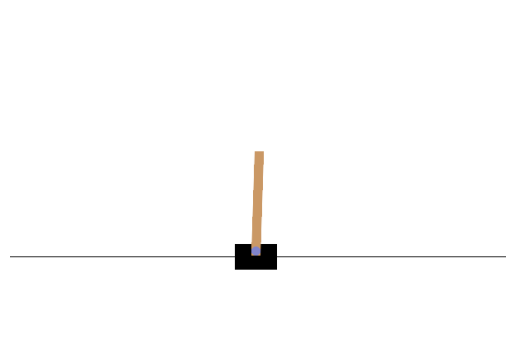

In [4]:
# Create environment
env = gym.make("CartPole-v1", render_mode="rgb_array")
# Print environment action and observation space and shape
print(f"Action Space: {env.action_space}\nObservation Space: {env.observation_space}")
print(f"Action Space Shape: {env.action_space.shape}\nObservation Space Shape: {env.observation_space.shape}")

# Reset environment 
observation, info = env.reset()
# observation: what the agent can "see" (cart position, velocity, pole angle, etc.)
# info: extra debugging info
print(f"Starting observation: {observation}")

fig, ax = plt.subplots()
img = ax.imshow(env.render())
ax.axis("off")

episode_over = False
total_reward = 0

while not episode_over:
    # Choose an aciton (0 = push cart left, 1 = push cart right)
    action = env.action_space.sample() # This is a random action for now (policy is to pick a random action with equal probs)
    
    # Take action and observe what happens
    observation, reward, terminated, truncated, info = env.step(action)
    
    # Add reward to cumulative reward
    total_reward += reward
    episode_over = terminated or truncated
    
print(f"Episode terminated! Total reward: {total_reward}")
env.close()

In [ ]:
from gymnasium.wrappers import TimeLimit

# Wrapping an environment to modify it to have longer time limit
env = gym.make("CartPole-v1", render_mode="rgb_array")
wrapped_env = TimeLimit(env, 1000)
observation, info = wrapped_env.reset()

episode_over = False
total_reward = 0

while not episode_over:
    action = wrapped_env.action_space.sample()
    
    observation, reward, terminated, truncated, info = wrapped_env.step(action)
    
    total_reward += reward
    episode_over = terminated or truncated
    
print(f"Episode terminated! Total reward: {total_reward}")
wrapped_env.close()
    

Episode terminated! Total reward: 19.0


: 

# Experiment 2: Training an Agent to play blackjack via Q-learning

Blackjack is perfect for RL training because of multiple reasons:
- Clear rules: Get closer to 21 without going over
- Simple observations: Your hand value, dealer's showing card, usable ace
- Discrete actions: Hit or stand
- Immediate feedback: Win, lose, or draw with each hand

As for the environment, we can set it up as follows (already set up in gymnasium):
- Observation: (player_sum, dealer_card, usable_ace)
  - `player_sum`: Current hand value (4-21)
  - `dealer_card`: Dealer's face-up card (1-10)
  - `usable_ace`: Whether the player has usable ace (True/False)
- Actions: 0 = Stand, 1 = Hit
- Rewards: +1 for win, -1 for loss, 0 for draw
- Episode ends: When player stands or busts 

When we execute an action via `env.step(action)`, we are returned the following values:
- `observation`: What the agent sees after taking the action (new game state)
- `reward`: Immediate feedback on the action (+1, -1, or 0)
- `terminated`: Whether the episode ended naturally (hand finished)
- `truncated`: Whether the episode cut short (time limits - not used here)
- `info`: Additional debugging info

The important thing to understand here is that `reward` tells us how good our *immediate* action was, but the agent needs to learn about *long-term* consequences. **Q-learning** handles this by estimating the total future rewards, not just the immediate one. It is an off-policy Temporal Difference (TD) control algorithm. It is value-based and works by building a lookup Q-table (2D matrix) that tells the agent how good each action is in each state:
- **Rows** = different situations (states) the agent can encounter
- **Columns** = different actions the agent can take
- **Values** = how good that action is in that situation (expected future reward)

An agent will use this **policy** (strategy that tells the agent what action to take in each situation to maximize long-term rewards) in the following learning process:
1. **Try an action** and see what happens (reward + new state)
2. **Update your cheat sheet**: "That actions was better/worse than I thought"
3. **Gradually improve** by trying actions and updating estimates
4. **Balance exploration and exploitation**: Try new things vs. use what you know works

**Why it works**: Over time, good actions get higher Q-values, bad actions get lower Q-values. The agent learns to pick actions with the highest expected rewards.

Our agent need the following functions:
1. **Choosing actions** (with exploration and exploitation)
2. **Learning from experience** (updating Q-values)
3. **Managing exploration** (reducing randomness over time)

We will use the **epsilon-greedy** strategy for balancing exploration and exploitation:
- With probability `epsilon`: choose a random action (explore)
- With probability `1-epsilon`: choose the best known action (exploit)
- Starting with high epsilon (lots of exploration) and gradually reducing it (more exploitations as we learn) works well in practice

We also use the **Bellman Optimality Equation**, which says the value of a state-action pair should equal the immediate reward plus the discounted value of the best next action.

In [2]:
class BlackjackAgent:
    def __init__(
        self,
        env: gym.Env,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay:float,
        final_epsilon: float,
        discount_factor: float = 0.95
    ):
        """Initialize a Q-Learning agent.

        Args:
            env: The training environment
            learning_rate: How quickly to update Q-values (0-1)
            initial_epsilon: Starting exploration rate (usually 1.0)
            epsilon_decay: How much to reduce epsilon each episode
            final_epsilon: Minimum exploration rate (usually 0.1)
            discount_factor: How much to value future rewards (0-1)
        """
        self.env = env
        
        # Q-tables: maps (state, action) to expected reward
        # defaultdict automatically creates entries with zeros for new states with the right num of columns (actions)
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))
        
        self.lr = learning_rate
        self.discount_factor = discount_factor # how much we discount future rewards (multiplicative)
        
        # Exploration parameters
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        
        # Track training progress
        self.training_error = []
        
    def get_action(self, obs: tuple[int, int, bool]) -> int:
        """Choose an action using epsilon-greedy strategy.

        Returns:
            action: 0 (stand) or 1 (hit)
        """
        # With probability epsilon: explore (random action)
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        
        # With probability 1-epsilon: exploitation (best known action, which is the column index)
        return int(np.argmax(self.q_values[obs])) # caching this could also help since this is an O(actions) operation
    
    def update(
        self,
        obs: tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple[int, int, bool],
    ):
        """Update Q-value based on experience.

        This is the heart of Q-learning: learn from (state, action, reward, next_state)
        """
        # Get current Q-value
        current_q_value = self.q_values[obs][action]
        
        # What's the best we could do from the next state?
        # (Zero if episode terminated - no future rewards possible)
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])
        
        # What should the Q-value for the current state be (Bellman optimality equation)
        target = reward + self.discount_factor * future_q_value
        
        # How wrong was our current estimate?
        temporal_difference = target - current_q_value
        
        # Update our current estimate in the direction of the error
        # Learning rate controls how big steps we take
        self.q_values[obs][action] = (
            current_q_value + self.lr * temporal_difference
        )
        
        # Track learning progress
        self.training_error.append(temporal_difference)
        
    def decay_epsilon(self):
        """Reduce exploration rate after each episode."""
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)
        

In [ ]:
# Training hyperparameters
learning_rate = 0.01
n_episodes = 100_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.1

# Create environment
env = gym.make("Blackjack-v1", sab=False) # sab stands for Sutton and Barto (changes the way rewards are assigned in the Blackjack game)
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

# Create training agent
agent = BlackjackAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

In [5]:
for episode in tqdm(range(n_episodes)):
    # Start a new hand
    obs, info = env.reset()
    done = False
    
    # Play one complete hand
    while not done:
        # Agent chooses action (initially random, gradually more intelligent)
        action = agent.get_action(obs)
        
        # Take action and observe result
        next_obs, reward, terminated, truncated, info = env.step(action)
        
        # Update current estimate
        agent.update(obs, action, reward, terminated, next_obs)
        
        # Move to next state
        done = terminated or truncated
        obs = next_obs
        
    # Reduce exploration rate
    agent.decay_epsilon()

100%|██████████| 100000/100000 [00:02<00:00, 34958.82it/s]


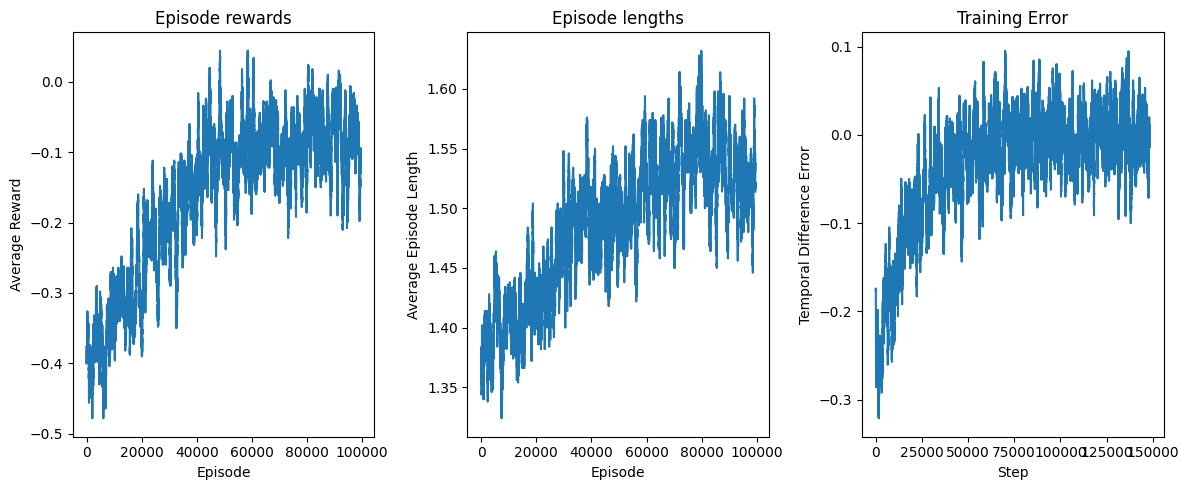

In [6]:
def get_moving_avgs(arr, window, convolution_mode):
    """Compute moving average to smooth noisy data."""
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    ) / window

# Smooth over a 500-episode window
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

# Episode rewards (win/loss performance)
axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    env.return_queue,
    rolling_length,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

# Episode lengths (how many actions per hand)
axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    env.length_queue,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")

# Training error (how much we're still learning)
axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    agent.training_error,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.show()

We can interpret the plots as follows:
- **Reward Plot**: The gradual improvement from -0.5 to -0.1 (near optimal theoretically) shows the reward increasing as the number of episodes grow. Blackjack is a game where the house has an edge, so we can never have  >= 0 reward.
- **Episode Length**: We can see that the average number of actions per episode increases, indicating that the agent is learning to not stand too early.
- **Training Error**: The temporal difference error starts negative (-0.3), which indicates that our Q-values (estimates) were larger than the target. As training continued, the target and our Q-values started to converge (bootstrapping value estimation works because Bellman equation shrinks gaps and grounding via real rewards through experiences anchors the target). If we did not have real rewards, we would diverge since the bootstrapping would be purely self-referential.

[Deadly Triad in RL (deep RL)](https://medium.com/@sophiezhao_2990/what-the-heck-is-bootstrapping-in-reinforcement-learning-0b6c8b2a1aa6)

In [15]:
def test_agent(agent, env, num_episodes=1000):
    """Test agent performance without learning or exploration"""
    total_rewards = []
    
    # Temporarily disable exploration
    old_epsilon = agent.epsilon
    agent.epsilon = 0.0
    
    for _ in range(num_episodes):
        obs, info = env.reset()
        episode_reward = 0
        done = False
        
        while not done:
            action = agent.get_action(tuple(obs))
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            done = terminated or truncated
            
        total_rewards.append(episode_reward)
        
    # Restore original epsilon
    agent.epsilon = old_epsilon
    
    win_rate = np.mean(np.array(total_rewards) > 0)
    average_reward = np.mean(total_rewards)
    
    print(f"Test Results over {num_episodes} episodes:")
    print(f"Win Rate: {win_rate:.1%}")
    print(f"Average Reward: {average_reward:.3f}")
    print(f"Standard Deviation: {np.std(total_rewards):.3f}")
    
test_agent(agent, env)
            

Test Results over 1000 episodes:
Win Rate: 100.0%
Average Reward: 9.337
Standard Deviation: 0.763


# Experiment 3: Training an agent on CartPole

In [19]:
class CartPoleAgent():
    def __init__(
        self,
        env: gym.Env,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay:float,
        final_epsilon: float,
        discount_factor: float = 0.95
    ):
        """Initialize a Q-Learning agent.

        Args:
            env: The training environment
            learning_rate: How quickly to update Q-values (0-1)
            initial_epsilon: Starting exploration rate (usually 1.0)
            epsilon_decay: How much to reduce epsilon each episode
            final_epsilon: Minimum exploration rate (usually 0.1)
            discount_factor: How much to value future rewards (0-1)
        """
        self.env = env
        
        # Q-tables: maps (state, action) to expected reward
        # defaultdict automatically creates entries with zeros for new states with the right num of columns (actions)
        # For the CartPole problem, we have the following:
        #   state: (cart_position, cart_velocity, pole_angle, and pole_angular_velocity)
        #   action: 0 = push cart left, 1 = push cart right
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))
        
        self.lr = learning_rate
        self.discount_factor = discount_factor # how much we discount future rewards (multiplicative)
        
        # Exploration parameters
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        
        # Track training progress
        self.training_error = []
        
    def get_action(self, obs: tuple[int, int, int, int]) -> int:
        """Choose an action using epsilon-greedy strategy.

        Returns:
            action: 0 (left) or 1 (right)
        """
        # With probability epsilon: explore (random action)
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        
        # With probability 1-epsilon: exploitation (best known action, which is the column index)
        return int(np.argmax(self.q_values[obs])) # caching this could also help since this is an O(actions) operation
    
    def update(
        self,
        obs: tuple[int, int, int, int],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple[int, int, int, int],
    ):
        """Update Q-value based on experience.

        This is the heart of Q-learning: learn from (state, action, reward, next_state)
        """
        # Get current Q-value
        current_q_value = self.q_values[obs][action]
        
        # What's the best we could do from the next state?
        # (Zero if episode terminated - no future rewards possible)
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])
        
        # What should the Q-value for the current state be (Bellman optimality equation)
        target = reward + self.discount_factor * future_q_value
        
        # How wrong was our current estimate?
        temporal_difference = target - current_q_value
        
        # Update our current estimate in the direction of the error
        # Learning rate controls how big steps we take
        self.q_values[obs][action] = (
            current_q_value + self.lr * temporal_difference
        )
        
        # Track learning progress
        self.training_error.append(temporal_difference)
        
    def decay_epsilon(self):
        """Reduce exploration rate after each episode."""
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)
        
def discretize(obs_bounds, n_bins, obs) -> tuple[int, int, int, int]:
    """Converts continuous values into discrete ones via bucketing"""
    bin_edges = [np.linspace(lo, hi, n+1)[1:-1] for (lo, hi), n in zip(obs_bounds, n_bins)]
    return tuple(int(np.digitize(x, edges)) for x, edges in zip(obs, bin_edges))
        
        
# Training hyperparameters
OBS_BOUNDS = [(-2.4, 2.4), (-3.0, 3.0), (-0.21, 0.21), (-3.5, 3.5)]
N_BINS = [6, 6, 12, 12]
learning_rate = 0.01
n_episodes = 100_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.1

# Create environment
env = gym.make("CartPole-v1")
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

# Create training agent
agent = CartPoleAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

for episode in tqdm(range(n_episodes)):
    # Start a new episode
    obs, info = env.reset()
    done = False
    
    # Finish episode (pole falls or time limit)
    while not done:
        # Agent chooses action (initially random, gradually more intelligent)
        action = agent.get_action(discretize(OBS_BOUNDS, N_BINS, obs))
        
        # Take action and observe result
        next_obs, reward, terminated, truncated, info = env.step(action)
        
        # Update current estimate
        agent.update(discretize(OBS_BOUNDS, N_BINS, obs), action, reward, terminated, discretize(OBS_BOUNDS, N_BINS, next_obs))
        
        # Move to next state
        done = terminated or truncated
        obs = next_obs
        
    # Reduce exploration rate
    agent.decay_epsilon()

100%|██████████| 100000/100000 [22:27<00:00, 74.20it/s]


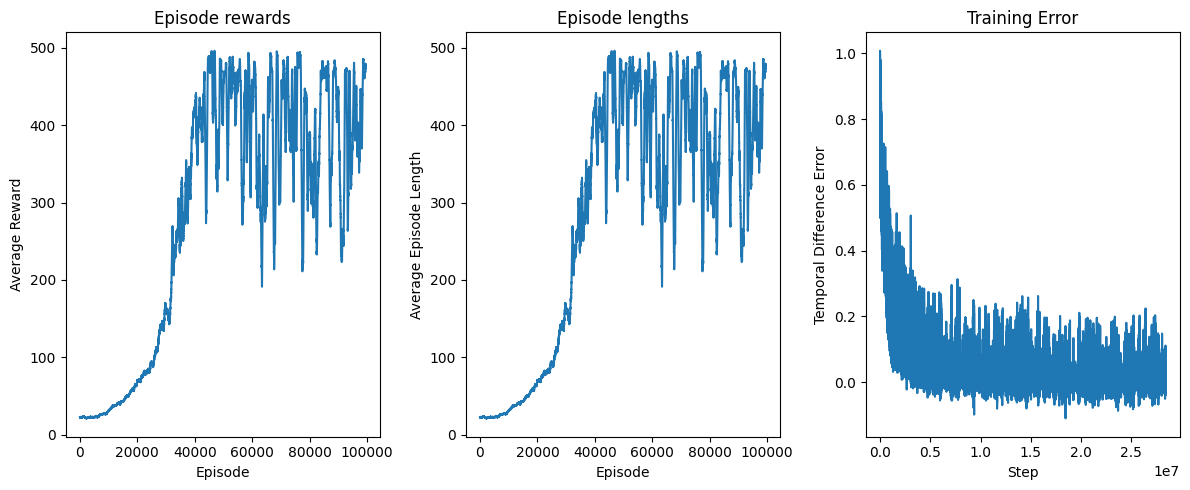

In [20]:
# Smooth over a 500-episode window
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

# Episode rewards (win/loss performance)
axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    env.return_queue,
    rolling_length,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

# Episode lengths (how many actions per hand)
axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    env.length_queue,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")

# Training error (how much we're still learning)
axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    agent.training_error,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.show()